## Project Overview

- Build a Natural Language Processing (NLP) model that classifies tweets into Positive, Negative, or Neutral sentiments. The project involves collecting tweet data, preprocessing text, converting text into numerical features using TF-IDF, training a machine learning model, and visualizing sentiment patterns.

## Objective

- Develop a sentiment classification system that automatically determines the emotional tone of tweets.

#### Libraries:

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing
pd.options.mode.chained_assignment = None
import zipfile #Unzipping the data

from wordcloud import WordCloud #Word visualization
import matplotlib.pyplot as plt #Plotting properties
import seaborn as sns #Plotting properties
from sklearn.feature_extraction.text import CountVectorizer #Data transformation
from sklearn.model_selection import train_test_split #Data testing
from sklearn.linear_model import LogisticRegression #Prediction Model
from sklearn.metrics import accuracy_score #Comparison between real and predicted
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder #Variable encoding and decoding for XGBoost
import re #Regular expressions
import nltk
from nltk import word_tokenize
nltk.download('stopwords')

import warnings
warnings.filterwarnings("ignore")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\vipul\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


- Unzipping the kaggle downloaded data

In [2]:
zip_file = "twitter_training.csv.zip" 
extract_path = "Twitter_data"     # Folder where files will be extracted

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Files extracted successfully!")

Files extracted successfully!


In [3]:
# load the dataset

df = pd.read_csv(r'\Twitter_data\twitter_training.csv',header = None, names = ['id','information','type','text'])
val_data = pd.read_csv(r'data\twitter_validation.csv',header = None, names = ['id','information','type','text'])

In [4]:
val_data.head()

,id,information,type,text
0,3364,Facebook,Irrelevant,I mentioned on Facebook that I was struggling ...
1,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
2,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
3,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
4,4433,Google,Neutral,Now the President is slapping Americans in the...


In [5]:
# load the dataset

df = pd.read_csv(r'\Twitter_data\twitter_training.csv',header = None, names = ['id','information','type','text'])

In [6]:
df.head(10)

,id,information,type,text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
5,2401,Borderlands,Positive,im getting into borderlands and i can murder y...
6,2402,Borderlands,Positive,So I spent a few hours making something for fu...
7,2402,Borderlands,Positive,So I spent a couple of hours doing something f...
8,2402,Borderlands,Positive,So I spent a few hours doing something for fun...
9,2402,Borderlands,Positive,So I spent a few hours making something for fu...


In [7]:
df.shape

(74682, 4)

#### data cleaning and preprocessing

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           74682 non-null  int64 
 1   information  74682 non-null  object
 2   type         74682 non-null  object
 3   text         73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [9]:
df.isnull().sum()

id               0
information      0
type             0
text           686
dtype: int64

- there is no null value in the dataset


- To prepare the data for the text analysis an additional row was created using the method of `str.lower`. However, as there were some texts with only numerical values (such as one that only had a 2 as the tweet) an additional function was used for transforming all the data to string.

- Then, a regex expression erased the special characters as it is common to have digitation problems on Twitter.

In [10]:
df["lower_text"] = df["text"].str.lower()  # convert text to lowercase
df['lower_text'] = [str(data) for data in df['lower_text']]  # convert all data to string
df["lower_text"] = df["lower_text"].apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', x))  # remove special characters and numbers

val_data["lower_text"] = val_data["text"].str.lower()  # convert text to lowercase
val_data['lower_text'] = [str(data) for data in val_data['lower_text']]  # convert all data to string
val_data["lower_text"] = val_data["lower_text"].apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', x))  # remove special characters and numbers

In [11]:
df.head(10)

,id,information,type,text,lower_text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...,i am coming to the borders and i will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...,im getting on borderlands and i will kill you all
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...,im getting on borderlands and i will murder y...
5,2401,Borderlands,Positive,im getting into borderlands and i can murder y...,im getting into borderlands and i can murder y...
6,2402,Borderlands,Positive,So I spent a few hours making something for fu...,so i spent a few hours making something for fu...
7,2402,Borderlands,Positive,So I spent a couple of hours doing something f...,so i spent a couple of hours doing something f...
8,2402,Borderlands,Positive,So I spent a few hours doing something for fun...,so i spent a few hours doing something for fun...
9,2402,Borderlands,Positive,So I spent a few hours making something for fu...,so i spent a few hours making something for fu...


# 2. Plotting features

- As to identify the main words that were used per label, a word_cloud was used to see which are the most important words on the train data. For example, on the positive label words such as love and game were mostly used alongside a wide variety of words classified as "good sentiments".

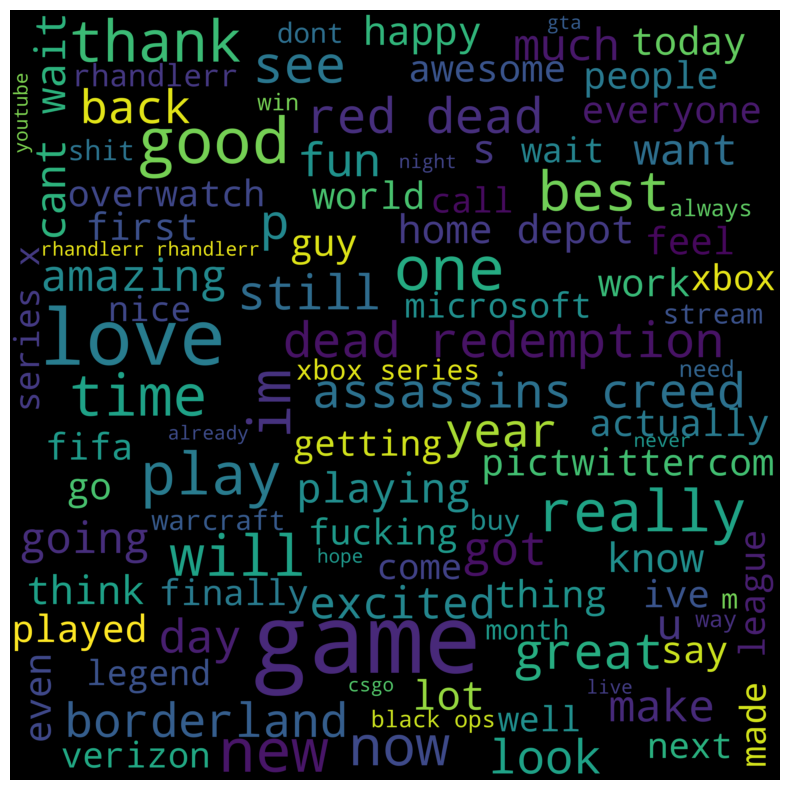

In [12]:

word_cloud_text = ''.join(df[df["type"]=="Positive"]["lower_text"])
#Creation of wordcloud
wordcloud = WordCloud(
    max_font_size=100,
    max_words=100,
    background_color="black",
    scale=10,
    width=800,
    height=800
).generate(word_cloud_text)
#Figure properties
plt.figure(figsize=(10,10))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

- As for the negative tweets, some curse words were the most important while the names of some games and industries were also very used, such as facebook and eamaddennfl. 

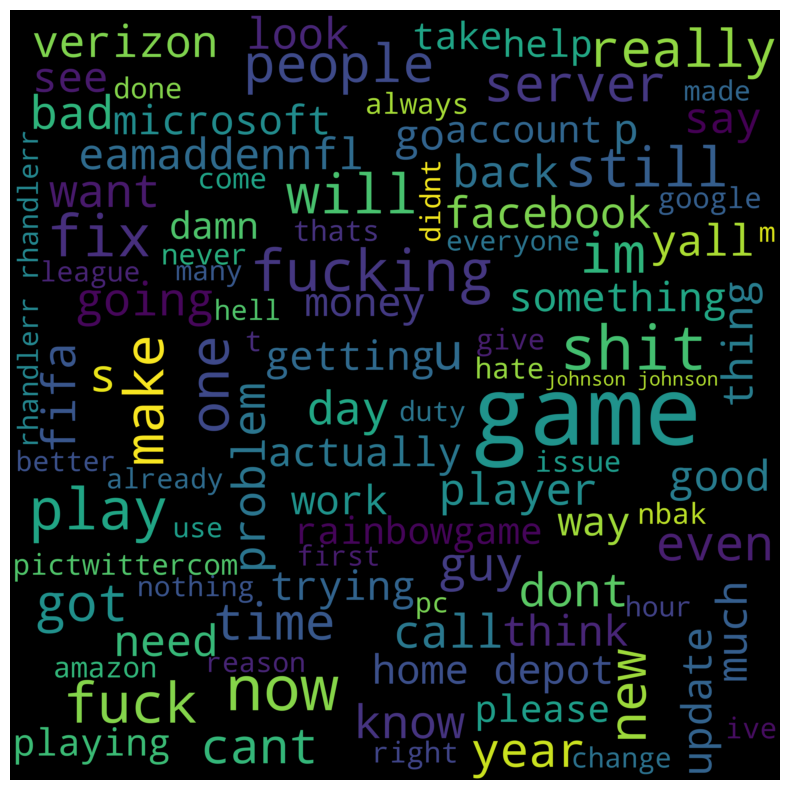

In [13]:
word_cloud_text = ''.join(df[df["type"]=="Negative"]["lower_text"])
#Creation of wordcloud
wordcloud = WordCloud(
    max_font_size=100,
    max_words=100,
    background_color="black",
    scale=10,
    width=800,
    height=800
).generate(word_cloud_text)
#Figure properties
plt.figure(figsize=(10,10))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

- The irrelevant tweets show a similar trend as negative ones, something that will impact the overall prediction performance.

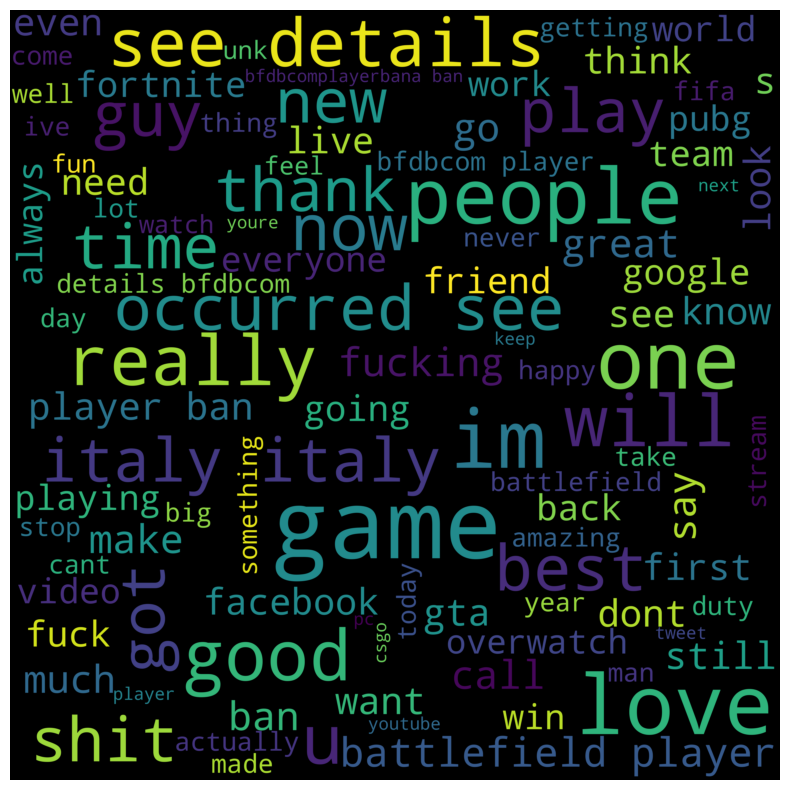

In [14]:
word_cloud_text = ''.join(df[df["type"]=="Irrelevant"]["lower_text"])
#Creation of wordcloud
wordcloud = WordCloud(
    max_font_size=100,
    max_words=100,
    background_color="black",
    scale=10,
    width=800,
    height=800
).generate(word_cloud_text)
#Figure properties
plt.figure(figsize=(10,10))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

- Then, on the neutral side, there are almost no curse words and the most important ones are different from the other 3 categories.

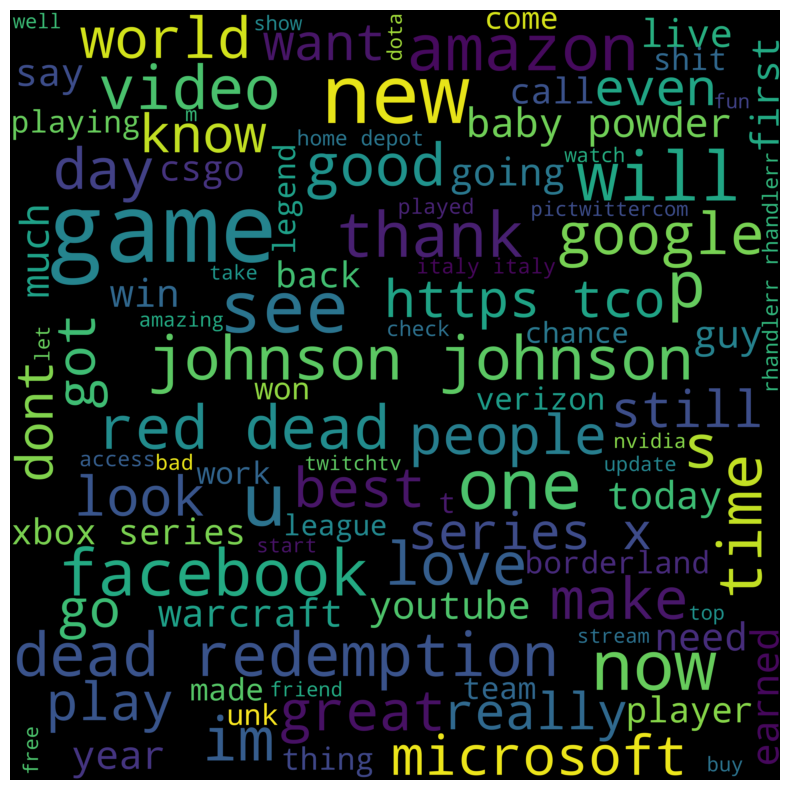

In [15]:
word_cloud_text = ''.join(df[df["type"]=="Neutral"]["lower_text"])
#Creation of wordcloud
wordcloud = WordCloud(
    max_font_size=100,
    max_words=100,
    background_color="black",
    scale=10,
    width=800,
    height=800
).generate(word_cloud_text)
#Figure properties
plt.figure(figsize=(10,10))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

- Finally, in this section, the information was grouped by the brand (or in this case the column information) to make a barplot that shows the number of tweets for each one.

Text(0.5, 1.0, 'Count of Tweets by Sentiment Type')

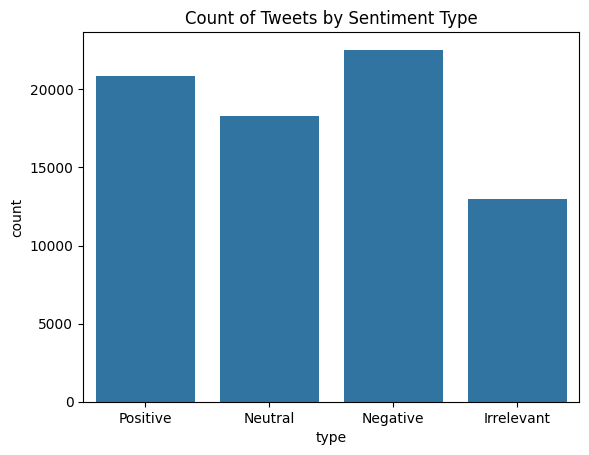

In [16]:
# count type per category

plot = sns.countplot(x='type', data=df)
plot.set_title("Count of Tweets by Sentiment Type")

In [17]:
#Count information per category
plot1=df.groupby(by=["information","type"]).count().reset_index()
plot1.head()

,information,type,id,text,lower_text
0,Amazon,Irrelevant,192,186,192
1,Amazon,Negative,576,575,576
2,Amazon,Neutral,1236,1207,1236
3,Amazon,Positive,312,308,312
4,ApexLegends,Irrelevant,192,192,192


- As an interesting fact, the number of modified texts coincides with the id. For this reason, as the ID is unique, the following barplot shows that for games such as MaddenNFL and NBA2K the number of negative tweets is the highest while on the other brands the trend is different.

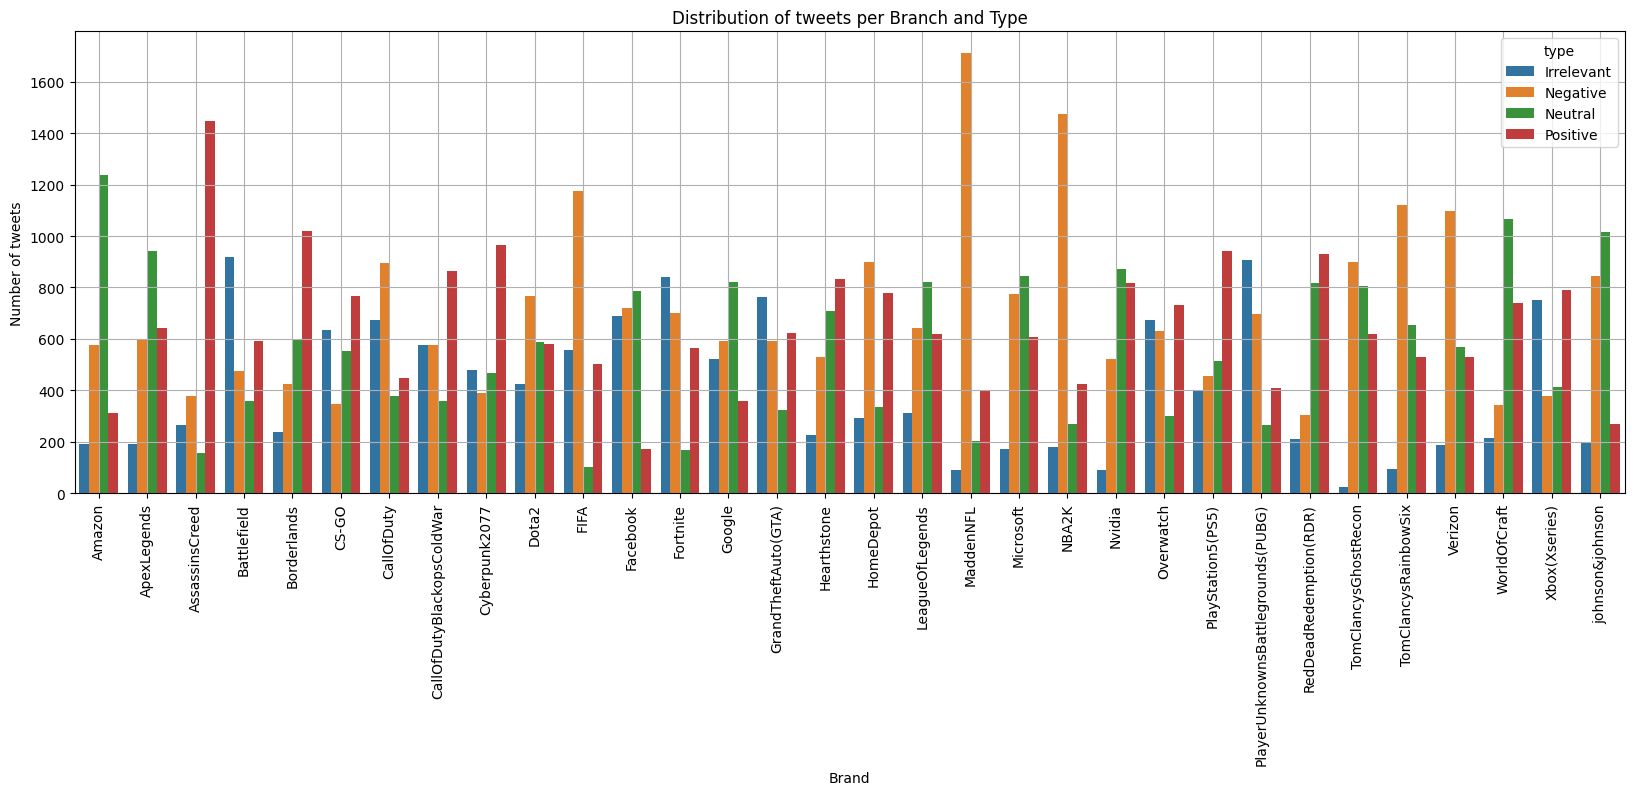

In [18]:
#Figure of comparison per branch
plt.figure(figsize=(20,6))
sns.barplot(data=plot1,x="information",y="id",hue="type")
plt.xticks(rotation=90)
plt.xlabel("Brand")
plt.ylabel("Number of tweets")
plt.grid()
plt.title("Distribution of tweets per Branch and Type");

# 3. Text analysis

- With the clean text, the initial number of unique tokens was counted to identify the model complexity. As presented, there are more than 30 thousand unique words.

In [19]:
#Text splitting
tokens_text = [word_tokenize(str(word)) for word in df["lower_text"]]
#Unique word counter
tokens_counter = [item for sublist in tokens_text for item in sublist]
print("Number of tokens: ", len(set(tokens_counter)))

Number of tokens:  38370


- The tokens_text variable groups all the texts by the different words stored on a List.

In [20]:
tokens_text[1]

['i',
 'am',
 'coming',
 'to',
 'the',
 'borders',
 'and',
 'i',
 'will',
 'kill',
 'you',
 'all']

- Also, the main English stopwords were saved on an additional variable, to be used in the following modeling.

In [21]:
#Choosing english stopwords
stopwords_nltk = nltk.corpus.stopwords
stop_words = stopwords_nltk.words('english')
stop_words[:5]

['a', 'about', 'above', 'after', 'again']

# 4. Logistic Regression model

For the main regression model, it was used a simple Logistic Regression of the sklearn library alongside the Bag of Words (BoW) approach. This last method helps to classify and group the relevant data to help the model identify the proper trends.

On this first BoW, the stopwords were considered alongside a default [ngram](https://deepai.org/machine-learning-glossary-and-terms/n-gram) of 1.

![Ngram.png](\Twitter_data\8ARA1.png)

In [22]:
#Initial Bag of Words
bow_counts = CountVectorizer(
    tokenizer=word_tokenize,
    stop_words=stop_words, #English Stopwords
    ngram_range=(1, 1) #analysis of one word
)

- Then, the main data was split on train and test datasets alongside the encoding of the words by using the training dataset as a reference:

In [23]:
#Train - Test splitting
reviews_train, reviews_test = train_test_split(df, test_size=0.2, random_state=0)

In [24]:
#Creation of encoding related to train dataset
X_train_bow = bow_counts.fit_transform(reviews_train["lower_text"])
#Transformation of test dataset with train encoding
X_test_bow = bow_counts.transform(reviews_test["lower_text"])

In [25]:
X_test_bow

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 149430 stored elements and shape (14937, 35735)>

In [26]:
#Labels for train and test encoding
y_train_bow = reviews_train['type']
y_test_bow = reviews_test['type']

- The total number of tweets for each category shows that negative and positive are the most registered while the irrelevant is the lowest.

In [27]:
#Total of registers per category
y_test_bow.value_counts() / y_test_bow.shape[0]

type
Negative      0.299190
Positive      0.282252
Neutral       0.245632
Irrelevant    0.172926
Name: count, dtype: float64

- With this data, the Logistic Regression Model was trained, where accuracy of 79% on the test dataset was obtained while on the validation dataset this value increased to 90%.

In [28]:
# Logistic regression
model1 = LogisticRegression(C=1, solver="liblinear",max_iter=200)
model1.fit(X_train_bow, y_train_bow)
# Prediction
test_pred = model1.predict(X_test_bow)
print("Accuracy: ", accuracy_score(y_test_bow, test_pred) * 100)

Accuracy:  79.44701077860347


In [29]:
#Validation data
X_val_bow = bow_counts.transform(val_data["lower_text"])
y_val_bow = val_data['type']

In [30]:
X_val_bow

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 11525 stored elements and shape (1000, 35735)>

In [31]:
Val_res = model1.predict(X_val_bow)
print("Accuracy: ", accuracy_score(y_val_bow, Val_res) * 100)

Accuracy:  90.7


Finally, another Bag of Words was used. This had an n-gram of 4 while not classifying the stopwords, using all the available information.

The Test dataset got to 90% while on the validation data the accuracy was 98%, showing that this approach was better than the simple n-gram and stopwords model.

In [32]:
#n-gram of 4 words
bow_counts = CountVectorizer(
    tokenizer=word_tokenize,
    ngram_range=(1,4)
)
#Data labeling
X_train_bow = bow_counts.fit_transform(reviews_train.lower_text)
X_test_bow = bow_counts.transform(reviews_test.lower_text)
X_val_bow = bow_counts.transform(val_data.lower_text)

In [33]:
X_train_bow

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 3800412 stored elements and shape (59745, 1401629)>

In [34]:
model2 = LogisticRegression(C=0.9, solver="liblinear",max_iter=1500)
# Logistic regression
model2.fit(X_train_bow, y_train_bow)
# Prediction
test_pred_2 = model2.predict(X_test_bow)
print("Accuracy: ", accuracy_score(y_test_bow, test_pred_2) * 100)

Accuracy:  89.54944098547232


In [35]:
y_val_bow = val_data['type']
Val_pred_2 = model2.predict(X_val_bow)
print("Accuracy: ", accuracy_score(y_val_bow, Val_pred_2) * 100)

Accuracy:  98.6



# XGBoost approach

As the data is already transformed, the additional step was to use another prediction modeling, such as the well know [XGBoost](https://xgboost.readthedocs.io/en/stable/). For this case, the last bag of words was used alongside the XGBoost Classifier:

In [36]:
# https://stackoverflow.com/questions/71996617/invalid-classes-inferred-from-unique-values-of-y-expected-0-1-2-3-4-5-got
le = LabelEncoder()
y_train_bow_num = le.fit_transform(y_train_bow)
y_test_bow_num=le.transform(y_test_bow)
y_val_bow_num=le.transform(y_val_bow)

In [37]:
%%time
XGB=XGBClassifier(objective="multi:softmax",n_estimators=1000,colsample_bytree=0.6, subsample=0.6)
XGB.fit(X_train_bow, y_train_bow_num)
# Prediction
test_pred_2 = XGB.predict(X_test_bow)
print("Accuracy: ", accuracy_score(y_test_bow_num, test_pred_2) * 100)

Accuracy:  82.91490928566645
CPU times: total: 5h 30min 36s
Wall time: 35min 33s


In [38]:
y_val_bow = val_data['type']
Val_pred_2 = XGB.predict(X_val_bow)
print("Accuracy: ", accuracy_score(y_val_bow_num, Val_pred_2) * 100)

Accuracy:  95.6


- At a first glance, with the default XGBoost parameters, the model gets a worse accuracy. For this reason, an additional cell was added to see the training performance:

In [39]:
test_pred_N = XGB.predict(X_train_bow)
print("Accuracy: ", accuracy_score(y_train_bow_num, test_pred_N) * 100)

Accuracy:  92.6052389321282


# Final remarks and future projects

![pexels-lukas-590022(2).jpg](https://images.pexels.com/photos/590022/pexels-photo-590022.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=1)

As presented in the notebook, a simple NLP approach helped to obtain a 90% accuracy on the test dataset, even with the labeling problems presented in the initial sections.

The next steps will be the improvement of accuracy with the use of winning competence models alongside an additional EDA analysis for checking labeling and context differences between each of the brands.